In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Feature Selection e Extraction
from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

**Limpeza (da entrega 2)**

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/MillenaNeves/Ciencia-de-dados/main/acidentes_recife_2024%20(1).csv', sep=';', decimal=',')

# Limpeza de colunas vazias e inúteis
colunas_vazias = ['situacao_semaforo', 'tempo_clima', 'acidente_verificado', 'mao_direcao', 'conservacao_via', 'ponto_controle', 'velocidade_max_via', 'divisao_via2', 'divisao_via1', 'num_semaforo', 'condicao_via', 'sinalizacao', 'situacao_placa']
colunas_inuteis_knn = ['Protocolo', 'endereco', 'numero', 'detalhe_endereco_acidente', 'complemento', 'bairro_cruzamento', 'data', 'hora']
df = df.drop(columns=colunas_vazias + colunas_inuteis_knn, errors='ignore')

# tratamento de nulos
features_cat = [col for col in df.columns if df[col].dtype == 'object' and col != 'natureza']
df[features_cat] = df[features_cat].fillna('DESCONHECIDO')

# tratamento de outliers
def tratar_outliers_iqr(dataframe, colunas, fator=1.5):
    df_out = dataframe.copy()
    for col in colunas:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        df_out[col] = df_out[col].clip(q1 - fator * iqr, q3 + fator * iqr)
    return df_out

features_num = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']
df = tratar_outliers_iqr(df, features_num)

**Separação, Encoding e StandardScaler**

In [ ]:
X = df[features_cat + features_num].copy()
y = df['natureza'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# encoding das variáveis categóricas
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = pd.DataFrame(encoder.fit_transform(X_train[features_cat]), columns=encoder.get_feature_names_out(features_cat))
X_test_cat = pd.DataFrame(encoder.transform(X_test[features_cat]), columns=encoder.get_feature_names_out(features_cat))

# resetando índices para concatenação
X_train_num = X_train[features_num].reset_index(drop=True)
X_test_num = X_test[features_num].reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# juntando numéricas e categóricas
X_train_full = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_full = pd.concat([X_test_num, X_test_cat], axis=1)

# padronização com StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_full), columns=X_test_full.columns)

print(f"Total de features após Encoding: {X_train_scaled.shape[1]}")

Total de features após Encoding: 125


**Funções Auxiliares e Modelo Baseline**

\n--- Baseline (Todas as Features) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.90      0.99      0.94      1402
  SEM VÍTIMA       0.71      0.24      0.36       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.90      1595
   macro avg       0.54      0.41      0.43      1595
weighted avg       0.87      0.90      0.87      1595



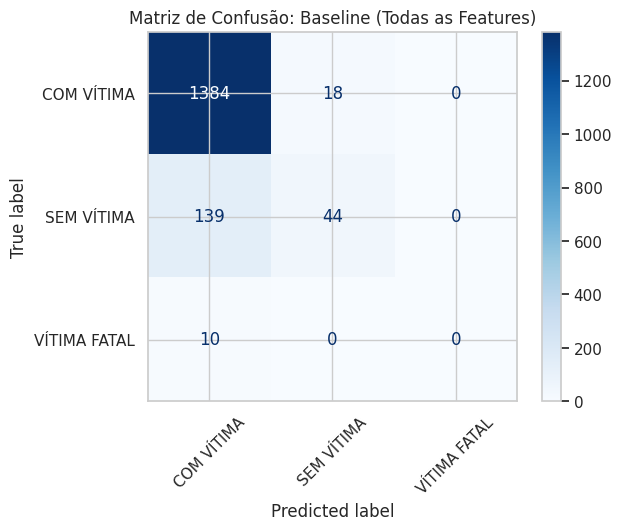

In [ ]:
resultados = []

def avaliar_modelo(X_tr, X_te, y_tr, y_te, nome_metodo):
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_tr, y_tr)
    y_pred = knn.predict(X_te)

    # métricas
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average='macro')

    print(f"\\n--- {nome_metodo} ---")
    print(classification_report(y_te, y_pred))

    # matriz de confusão
    disp = ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Blues', xticks_rotation=45)
    plt.title(f'Matriz de Confusão: {nome_metodo}')
    plt.show()

    resultados.append({
        'Método': nome_metodo,
        'Acurácia': acc,
        'F1-Score': f1,
        'Num_Features': X_tr.shape[1]
    })

# modelo baseline sem seleção de features
avaliar_modelo(X_train_scaled, X_test_scaled, y_train, y_test, 'Baseline (Todas as Features)')

**Estratégias de seleção e extração**

Iniciando Filter Method (SelectKBest)...
\n--- Filter: SelectKBest (k=15) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.93      0.97      0.95      1402
  SEM VÍTIMA       0.67      0.45      0.54       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.91      1595
   macro avg       0.53      0.47      0.50      1595
weighted avg       0.89      0.91      0.89      1595



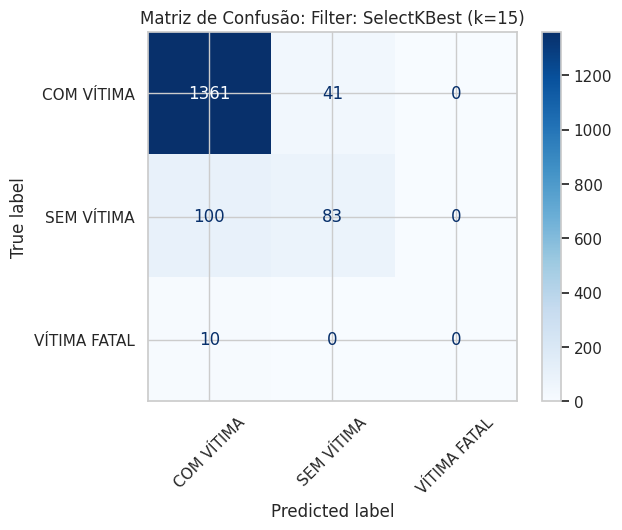


Iniciando Wrapper Method: SFS Forward (Pode demorar alguns minutos)...
\n--- Wrapper: Forward (10 features) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.99      0.95      1402
  SEM VÍTIMA       0.79      0.43      0.55       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.91      1595
   macro avg       0.57      0.47      0.50      1595
weighted avg       0.90      0.91      0.90      1595



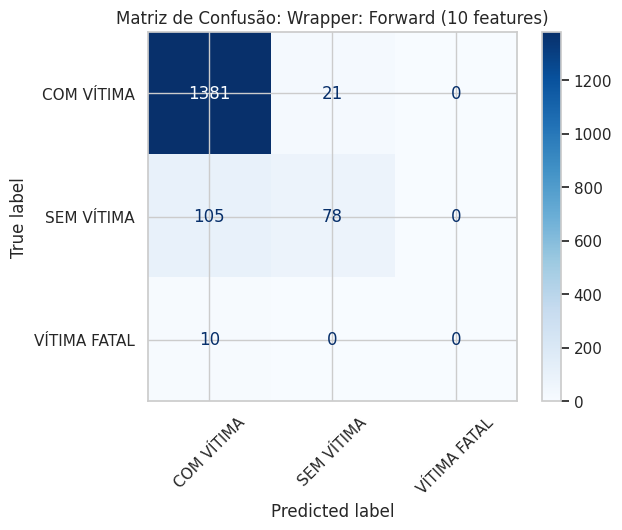


Iniciando Wrapper Method: SFS Backward (Esse é o mais demorado, aguarde)...
\n--- Wrapper: Backward (10 features) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.99      0.95      1402
  SEM VÍTIMA       0.77      0.38      0.51       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.91      1595
   macro avg       0.56      0.45      0.49      1595
weighted avg       0.89      0.91      0.89      1595



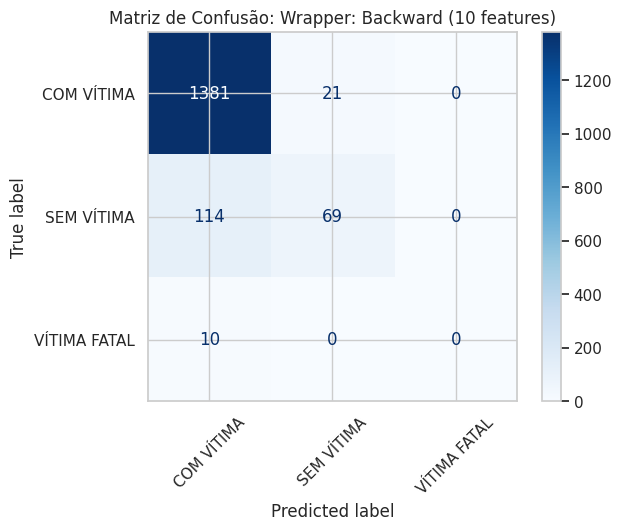


Iniciando Embedded Method (Regressão Logística L1)...
\n--- Embedded: Logistic Regression L1 ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.90      0.99      0.94      1402
  SEM VÍTIMA       0.71      0.26      0.38       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.90      1595
   macro avg       0.54      0.41      0.44      1595
weighted avg       0.88      0.90      0.87      1595



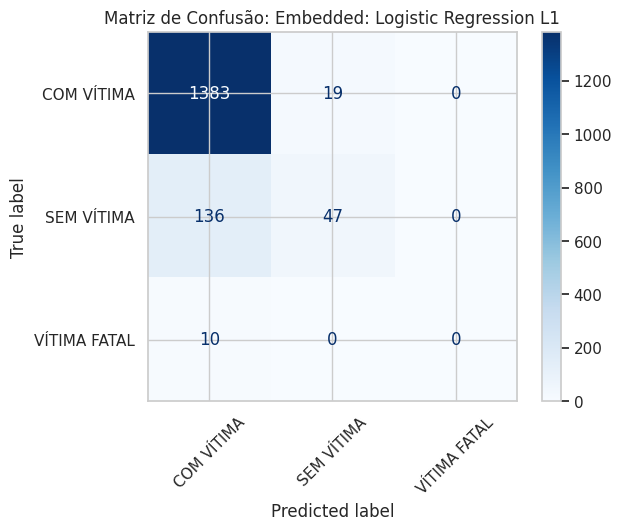


Iniciando Feature Extraction (PCA)...
\n--- Extraction: PCA (n=2) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.97      0.94      1402
  SEM VÍTIMA       0.62      0.40      0.49       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.90      1595
   macro avg       0.51      0.46      0.48      1595
weighted avg       0.88      0.90      0.88      1595



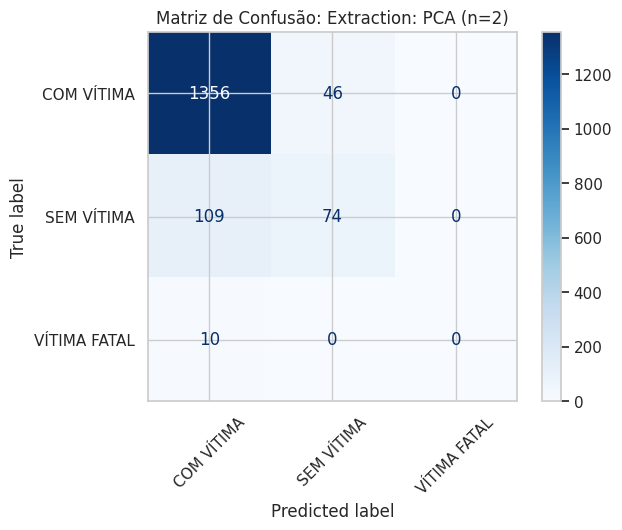

\n--- Extraction: PCA (n=3) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.97      0.95      1402
  SEM VÍTIMA       0.66      0.40      0.50       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.90      1595
   macro avg       0.53      0.46      0.48      1595
weighted avg       0.88      0.90      0.89      1595



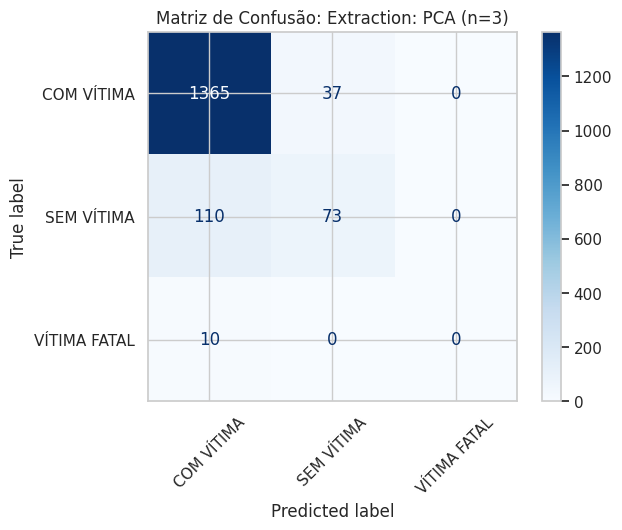

\n--- Extraction: PCA (n=5) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.98      0.95      1402
  SEM VÍTIMA       0.69      0.37      0.48       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.90      1595
   macro avg       0.54      0.45      0.48      1595
weighted avg       0.89      0.90      0.89      1595



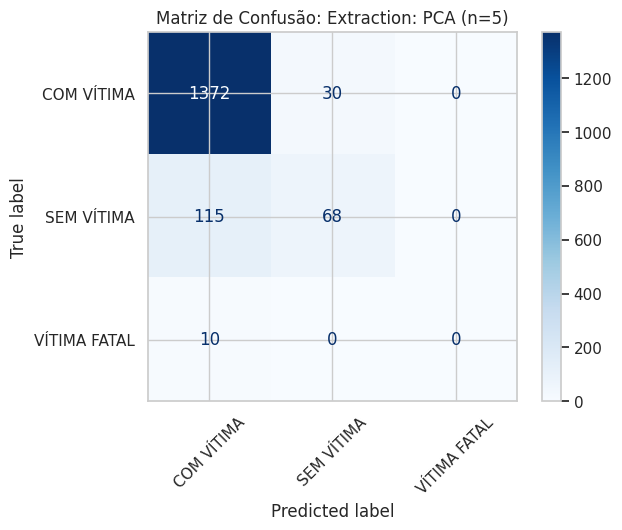

\n--- Extraction: PCA (n=10) ---
              precision    recall  f1-score   support

  COM VÍTIMA       0.92      0.98      0.95      1402
  SEM VÍTIMA       0.74      0.39      0.51       183
VÍTIMA FATAL       0.00      0.00      0.00        10

    accuracy                           0.91      1595
   macro avg       0.55      0.46      0.49      1595
weighted avg       0.89      0.91      0.89      1595



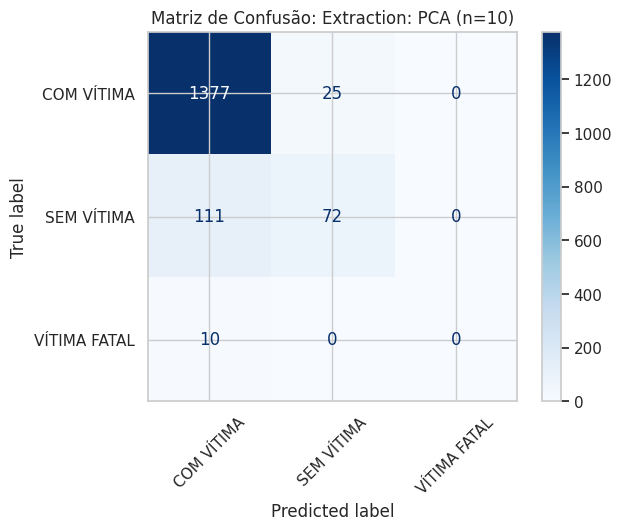


Todos os métodos finalizados com sucesso!


In [ ]:
# 1. Filter Method: SelectKBest (ANOVA)
print("Iniciando Filter Method (SelectKBest)...")
selector_kbest = SelectKBest(score_func=f_classif, k=15)
X_train_kbest = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector_kbest.transform(X_test_scaled)
avaliar_modelo(X_train_kbest, X_test_kbest, y_train, y_test, 'Filter: SelectKBest (k=15)')


# 2. Wrapper Methods: SequentialFeatureSelector (SFS)
knn_wrap = KNeighborsClassifier(n_neighbors=5)

print("\nIniciando Wrapper Method: SFS Forward (Pode demorar alguns minutos)...")
sfs_forward = SequentialFeatureSelector(knn_wrap, n_features_to_select=10, direction='forward', cv=2)
X_train_forw = sfs_forward.fit_transform(X_train_scaled, y_train)
X_test_forw = sfs_forward.transform(X_test_scaled)
avaliar_modelo(X_train_forw, X_test_forw, y_train, y_test, 'Wrapper: Forward (10 features)')

print("\nIniciando Wrapper Method: SFS Backward (Esse é o mais demorado, aguarde)...")
sfs_backward = SequentialFeatureSelector(knn_wrap, n_features_to_select=10, direction='backward', cv=2)
X_train_back = sfs_backward.fit_transform(X_train_scaled, y_train)
X_test_back = sfs_backward.transform(X_test_scaled)
avaliar_modelo(X_train_back, X_test_back, y_train, y_test, 'Wrapper: Backward (10 features)')


# 3. Embedded Methods: SelectFromModel (Regressão Logística com L1)
print("\nIniciando Embedded Method (Regressão Logística L1)...")
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
selector_emb = SelectFromModel(lr_l1)
X_train_emb = selector_emb.fit_transform(X_train_scaled, y_train)
X_test_emb = selector_emb.transform(X_test_scaled)
avaliar_modelo(X_train_emb, X_test_emb, y_train, y_test, 'Embedded: Logistic Regression L1')


# 4. Feature Extraction: PCA (2, 3, 5, 10 componentes)
print("\nIniciando Feature Extraction (PCA)...")
for n_comp in [2, 3, 5, 10]:
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    avaliar_modelo(X_train_pca, X_test_pca, y_train, y_test, f'Extraction: PCA (n={n_comp})')

print("\nTodos os métodos finalizados com sucesso!")

**Visualização comparativa**

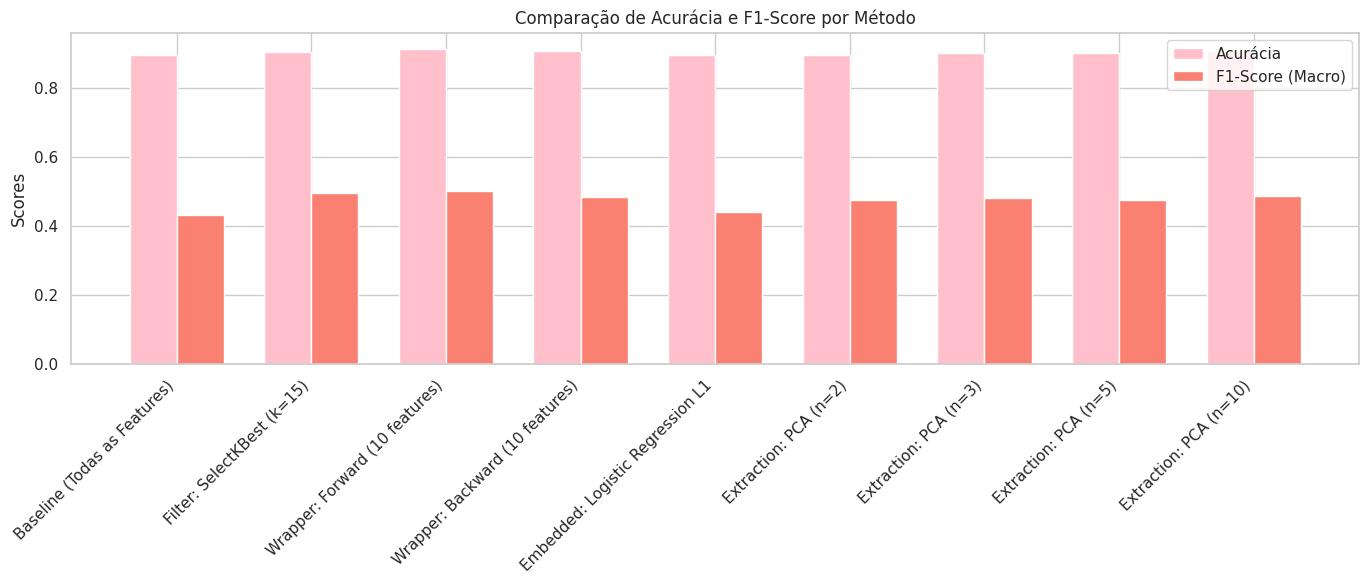

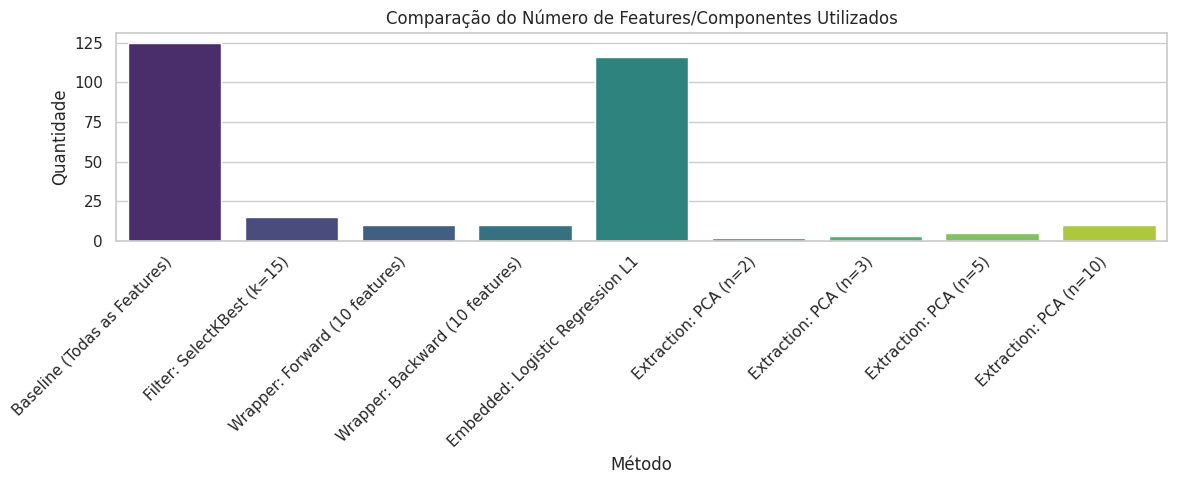

In [ ]:
df_res = pd.DataFrame(resultados)

# gráfico 1: acurácia e F1-Score
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_res['Método']))
width = 0.35

ax.bar(x - width/2, df_res['Acurácia'], width, label='Acurácia', color='pink')
ax.bar(x + width/2, df_res['F1-Score'], width, label='F1-Score (Macro)', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Comparação de Acurácia e F1-Score por Método')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Método'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# gráfico 2: número de features/componentes
plt.figure(figsize=(12, 5))
sns.barplot(x='Método', y='Num_Features', data=df_res, palette='viridis')
plt.title('Comparação do Número de Features/Componentes Utilizados')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()